# Introduction to Cluster Analysis

**Cluster Analysis** (or **Clustering**) is a fundamental Unsupervised Machine Learning technique. Unlike Supervised Learning, which relies on labeled datasets, Unsupervised Learning discovers hidden structures in unlabeled data.

### What is a Cluster?
A cluster is a collection of data points aggregated together based on specific similarities. In a successful clustering model:

1.  **High Intra-cluster similarity:** Data points within the same group are very similar to one another.
2.  **Low Inter-cluster similarity:** Data points in different groups are as distinct from each other as possible.

In simple terms, it's about grouping similar items together based on rules like distance, density, or statistical probability.

### Key Objectives of Clustering

*   **Exploratory Data Analysis (EDA):** Getting to know your data by seeing how it naturally groups.
*   **Data Compression:** Representing a large dataset by its cluster centers.
*   **Pattern Recognition:** Identifying underlying structures (e.g., identifying different species of flowers based on petal size).

### Foundational Terminology

*   **Distance Metric:** The mathematical formula used to determine how 'similar' or 'dissimilar' two points are. Common examples include *Euclidean Distance* (straight line) and *Manhattan Distance* (city block).
*   **Centroid:** The 'center' of a cluster, often calculated as the average of all points in that cluster.
*   **Feature Space:** The multi-dimensional space where your data points live, based on the variables (features) you are analyzing.
*   **Dimensionality:** The number of features or variables used for clustering.

## Major Clustering Algorithms

There are several ways to group data, but two of the most common are:

1.  **K-Means Clustering:** An algorithm that divides data into *K* groups by minimizing the distance between points and the center (centroid) of their cluster. It's best for finding spherical, well-separated groups.
2.  **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** This method groups points that are closely packed together and marks points in low-density regions as outliers. Unlike K-Means, it can find clusters of any shape.

---

## How Cluster Analysis Works (Step-by-Step)

1.  **Feature Selection:** Choose which variables (e.g., age, income, spending score) are relevant to the patterns you want to find.
2.  **Decide the Number of Clusters:** Depending on the method, you might specify this manually (like in K-Means) or let the algorithm determine it (like in DBSCAN).
3.  **Apply the Algorithm:** Run the mathematical model to assign each data point to a group.
4.  **Evaluate the Results:** Use visual inspection or metrics like the **Silhouette Score** to see how well-defined the clusters are.
5.  **Interpret & Use:** Label the clusters (e.g., "High-Value Customers") and use these insights for business or research decisions.

## Step-by-Step Working of K-Means

| Step | Action | Description |
| :--- | :--- | :--- |
| **Step 1** | **Choose K** | Select the number of clusters you want to create before running the algorithm. |
| **Step 2** | **Initialize Centroids** | Randomly place K points in the feature space. These act as the initial centers of your clusters. |
| **Step 3** | **Assignment** | Assign each data point to the nearest centroid based on a distance metric (e.g., Euclidean distance). |
| **Step 4** | **Update Centroids** | Calculate the new center for each cluster by taking the mean (average) of all points currently assigned to it. |
| **Step 5** | **Repeat** | Repeat Steps 3 and 4 until points stop changing clusters (convergence), centroids stop moving, or a max iteration limit is reached. |

**Final Output:** You get K optimized clusters, with each data point assigned to the group where it fits best mathematically.

In [1]:
import pandas as pd
df = pd.read_csv('shopping_data.csv')
print(df.head(10))
df.info()

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Custom

### Data Visualization
Before applying K-Means, we visualize the data to see if any natural clusters are visible between **Annual Income** and **Spending Score**.

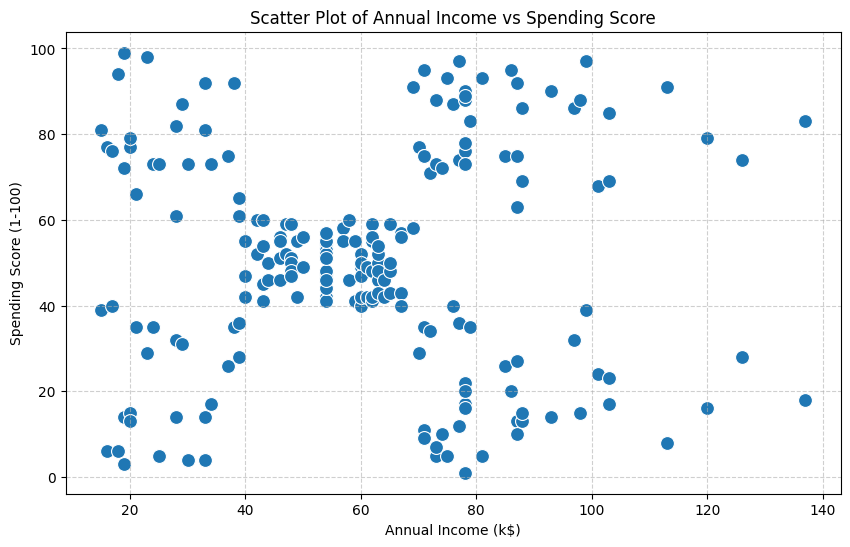

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', s=100)
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Finding the Optimal K: The Elbow Method

One of the most challenging tasks in K-Means is choosing the right number of clusters (**K**).

### The Elbow Method Explained:
1. We run K-Means for a range of K values (e.g., 1 to 10).
2. For each K, we calculate the **WCSS** (Within-Cluster Sum of Squares) — which is the sum of squared distances between each point and its centroid.
3. We plot K versus WCSS.
4. As K increases, WCSS decreases. We look for the 'elbow' point where the rate of decrease shifts significantly. This point represents the optimal balance between cluster count and data fit.

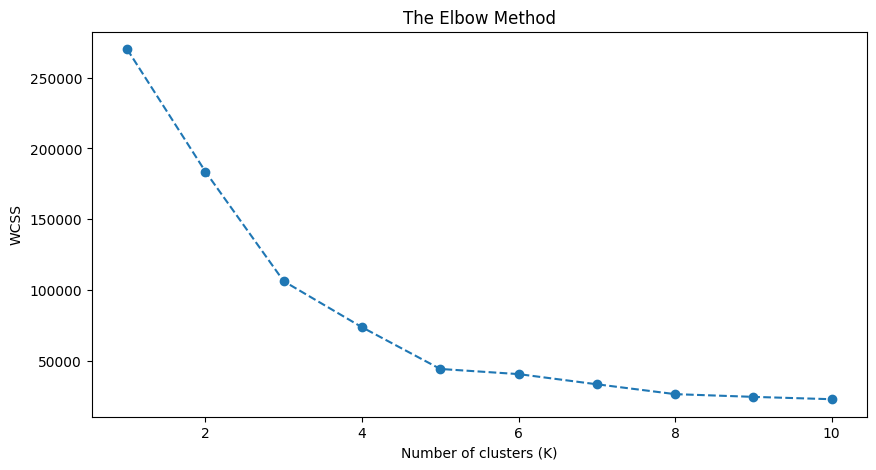

In [3]:
from sklearn.cluster import KMeans

# Selecting features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [4]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
df['Cluster'] = kmeans.fit_predict(X)

print("Centroids:")
print(kmeans.cluster_centers_)

Centroids:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [5]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


## Final K-Means Model (K=5)

Based on the Elbow Method, we select **K=5**. We will now:
1. Train the K-Means model with 5 clusters.
2. Assign each customer to a cluster.
3. Visualize the 5 distinct customer segments and their centroids.

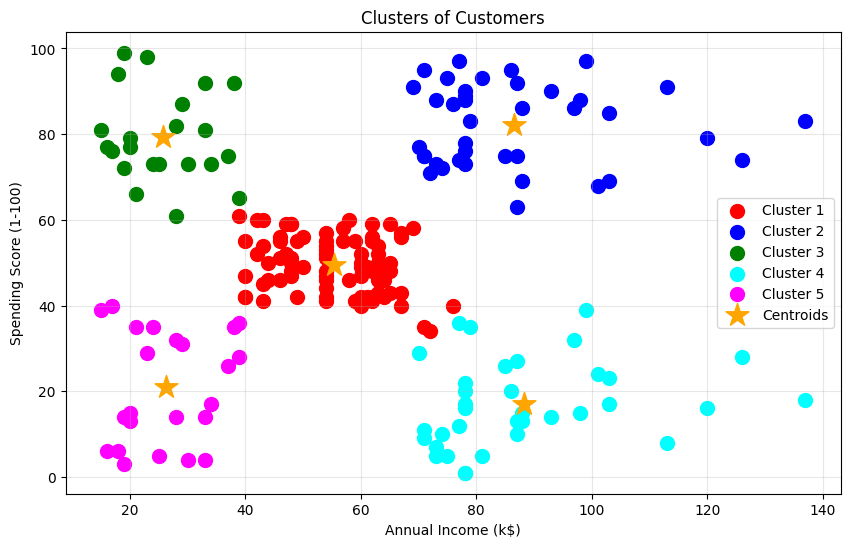

In [6]:
# Final Model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
    # Use .iloc to access column indices 0 and 1 for the filtered rows
    cluster_subset = df[df['Cluster'] == i]
    plt.scatter(cluster_subset.iloc[:, 3], cluster_subset.iloc[:, 4], s=100, c=colors[i], label=labels[i])

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='orange',
            label='Centroids',
            marker='*')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Interpreting the Clusters

In a real-world scenario, we would label these clusters based on their characteristics to drive marketing strategies:

*   **Target Group (High Income, High Spending):** Customers who earn a lot and spend a lot. (Marketing: Loyalty programs).
*   **Careful (High Income, Low Spending):** High earners who are cautious with their money. (Marketing: Premium offers/value propositions).
*   **Standard (Average Income, Average Spending):** The middle-ground consumers. (Marketing: General promotions).
*   **Spendthrifts (Low Income, High Spending):** Low earners who spend frequently. (Marketing: Flash sales).
*   **Sensible (Low Income, Low Spending):** Consumers who earn less and are frugal. (Marketing: Discounts).

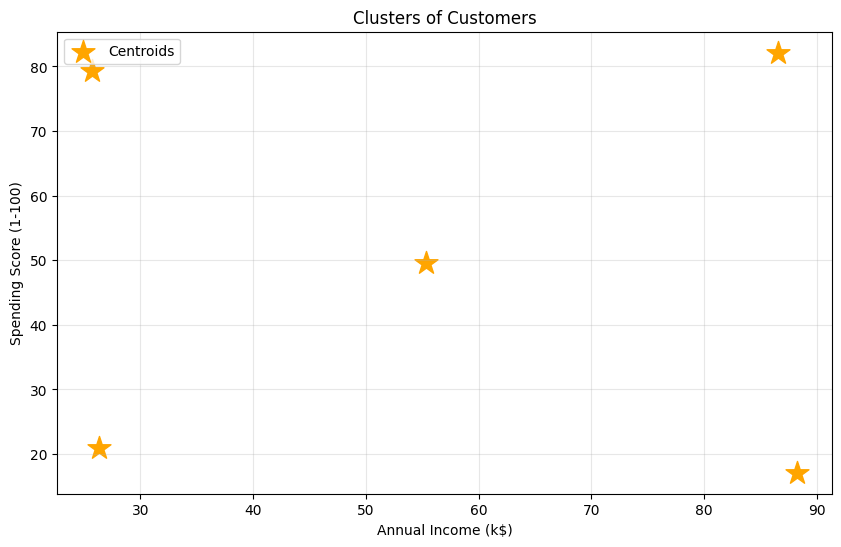

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='orange',
    label='Centroids',
    marker='*'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters of Customers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

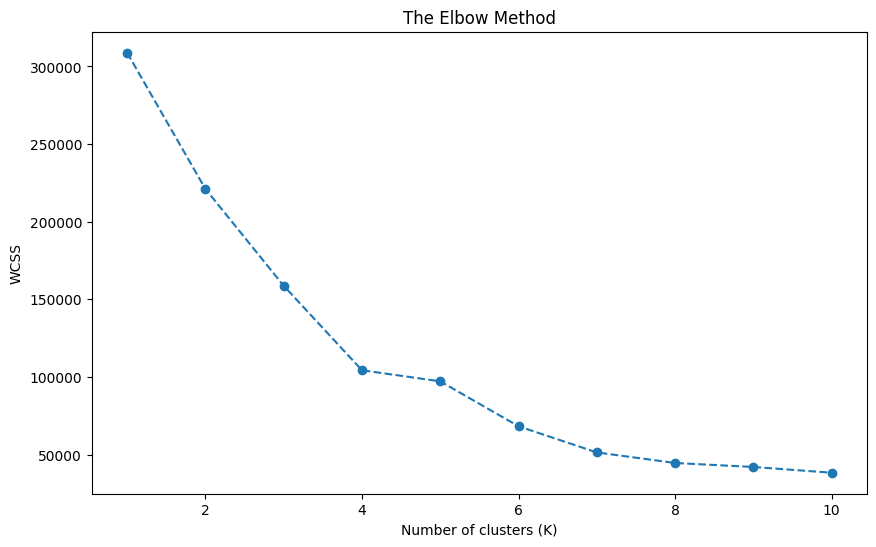

In [8]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42, n_init = 'auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (10,6))
plt.plot(range(1,11), wcss, marker = 'o', linestyle = '--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [9]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, n_init = 'auto')
df['Cluster'] = kmeans.fit_predict(X)

print("Centroids:")
print(kmeans.cluster_centers_)

Centroids:
[[44.89473684 48.70526316 42.63157895]
 [32.69230769 86.53846154 82.12820513]
 [24.82142857 28.71428571 74.25      ]
 [40.39473684 87.         18.63157895]]


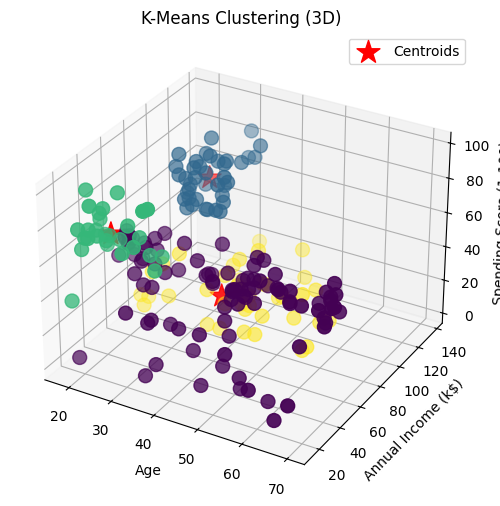

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Age'],
           df['Annual Income (k$)'],
           df['Spending Score (1-100)'],
           c=df['Cluster'],
           cmap='viridis',
           marker='o',
           s=100
)

ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=300,
    c='red',
    label='Centroids',
    marker='*'
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('K-Means Clustering (3D)')
ax.legend()
plt.show()

In [11]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Create the base 3D scatter plot for the data points
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster',
    title='Interactive 3D Clusters with Centroids',
    opacity=0.7,
    color_continuous_scale='Viridis'
)

# Create a DataFrame for the centroids
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

# Add the centroids as a separate trace
fig.add_trace(
    go.Scatter3d(
        x=centroids_df['Age'],
        y=centroids_df['Annual Income (k$)'],
        z=centroids_df['Spending Score (1-100)'],
        mode='markers',
        marker=dict(
            size=10,
            color='red',
            symbol='diamond',
            line=dict(width=2, color='white')
        ),
        name='Centroids'
    )
)

# fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))

# Adjust the layout to expand the Age axis and create a cube look
fig.update_layout(
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Annual Income (k$)',
        zaxis_title='Spending Score (1-100)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1) # Equal ratio for all axes creates a cube
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()

In [12]:
import plotly.express as px
import plotly.graph_objects as go

# Re-running K-Means with K=6
kmeans_6 = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init='auto')
df['Cluster_K6'] = kmeans_6.fit_predict(X)

# Create the interactive 3D scatter plot for K=6
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster_K6',
    title='Interactive 3D Clusters (K = 6)',
    opacity=0.7,
    color_continuous_scale='Viridis'
)

# Add the centroids for K=6
centroids_6 = pd.DataFrame(kmeans_6.cluster_centers_, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

fig.add_trace(
    go.Scatter3d(
        x=centroids_6['Age'],
        y=centroids_6['Annual Income (k$)'],
        z=centroids_6['Spending Score (1-100)'],
        mode='markers',
        marker=dict(
            size=10,
            color='red',
            symbol='diamond',
            line=dict(width=3, color='black')
        ),
        name='Centroids'
    )
)

# Adjust the layout to expand the Age axis and create a cube look
fig.update_layout(
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Annual Income (k$)',
        zaxis_title='Spending Score (1-100)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1) # Equal ratio for all axes creates a cube
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

In [13]:
# Running K-Means with the mathematical peak K=7
kmeans_7 = KMeans(n_clusters=7, init='k-means++', random_state=42, n_init='auto')
df['Cluster_K7'] = kmeans_7.fit_predict(X)

# Create the interactive 3D scatter plot for K=7
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster_K7',
    title='Mathematical Peak: Interactive 3D Clusters (K=7)',
    opacity=0.7,
    color_continuous_scale='Viridis'
)

# Add the centroids for K=7
centroids_7 = pd.DataFrame(kmeans_7.cluster_centers_, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

fig.add_trace(
    go.Scatter3d(
        x=centroids_7['Age'],
        y=centroids_7['Annual Income (k$)'],
        z=centroids_7['Spending Score (1-100)'],
        mode='markers',
        marker=dict(
            size=10,
            color='red',
            symbol='diamond',
            line=dict(width=3, color='black')
        ),
        name='Centroids'
    )
)

fig.update_layout(
    scene=dict(
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

### Cluster Size Comparison
To check if our segments are actionable, we need to see the distribution of customers across each cluster.

In [14]:
# Count points in each cluster for K=6
k6_counts = df['Cluster_K6'].value_counts().sort_index()

# Count points in each cluster for K=7
k7_counts = df['Cluster_K7'].value_counts().sort_index()

print("--- K=6 Cluster Sizes ---")
print(k6_counts)
print(f"\nSmallest Cluster Size: {k6_counts.min()}")

print("\n--- K=7 Cluster Sizes ---")
print(k7_counts)
print(f"\nSmallest Cluster Size: {k7_counts.min()}")

--- K=6 Cluster Sizes ---
Cluster_K6
0    76
1    10
2    25
3    37
4    29
5    23
Name: count, dtype: int64

Smallest Cluster Size: 10

--- K=7 Cluster Sizes ---
Cluster_K7
0    44
1     7
2    23
3    34
4    32
5    22
6    38
Name: count, dtype: int64

Smallest Cluster Size: 7


In [15]:
# Calculate mean values for each cluster in K=6 to identify the 'Small' group
cluster_6_analysis = df.groupby('Cluster_K6')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_6_analysis['Count'] = df['Cluster_K6'].value_counts().sort_index()

print("--- K=6 Cluster Profiling ---")
display(cluster_6_analysis.sort_values(by='Count'))

--- K=6 Cluster Profiling ---


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster_K6,,,,
1,32.200000,109.700000,82.000000,10
5,45.217391,26.304348,20.913043,23
2,24.960000,28.040000,77.000000,25
4,32.862069,78.551724,82.172414,29
3,40.324324,87.432432,18.189189,37
0,43.934211,55.210526,49.447368,76


In [16]:
# Adding the descriptive labels we just created
cluster_map = {
    1: 'Young & High Income (VIP)',
    4: 'Young & Mid-Income (Active)',
    2: 'Young & Budget (Impulsive)',
    0: 'Middle-Aged (Standard)',
    3: 'Middle-Aged & High Income (Cautious)',
    5: 'Middle-Aged & Budget (Frugal)'
}

cluster_6_analysis['Description'] = pd.Series(cluster_map)

print("--- Final K=6 Customer Segment Profiles ---")
display(cluster_6_analysis.sort_values(by='Count', ascending=False))

--- Final K=6 Customer Segment Profiles ---


,Age,Annual Income (k$),Spending Score (1-100),Count,Description
Cluster_K6,,,,,
0,43.934211,55.210526,49.447368,76,Middle-Aged (Standard)
3,40.324324,87.432432,18.189189,37,Middle-Aged & High Income (Cautious)
4,32.862069,78.551724,82.172414,29,Young & Mid-Income (Active)
2,24.960000,28.040000,77.000000,25,Young & Budget (Impulsive)
5,45.217391,26.304348,20.913043,23,Middle-Aged & Budget (Frugal)
1,32.200000,109.700000,82.000000,10,Young & High Income (VIP)


In [17]:
cluster_map = {
    1: 'Young & High Income (VIP)',
    4: 'Young & Mid-Income (Active)',
    2: 'Young & Budget (Impulsive)',
    0: 'Middle-Aged (Standard)',
    3: 'Middle-Aged & High Income (Cautious)',
    5: 'Middle-Aged & Budget (Frugal)'
}

df['Cluster_Description'] = df['Cluster_K6'].map(cluster_map)

# Displaying sample results
display(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_Description']].head(15))

,Age,Annual Income (k$),Spending Score (1-100),Cluster_Description
0,19,15,39,Middle-Aged & Budget (Frugal)
1,21,15,81,Young & Budget (Impulsive)
2,20,16,6,Middle-Aged & Budget (Frugal)
3,23,16,77,Young & Budget (Impulsive)
4,31,17,40,Middle-Aged & Budget (Frugal)
5,22,17,76,Young & Budget (Impulsive)
6,35,18,6,Middle-Aged & Budget (Frugal)
7,23,18,94,Young & Budget (Impulsive)
8,64,19,3,Middle-Aged & Budget (Frugal)
9,30,19,72,Young & Budget (Impulsive)


In [18]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for K=4
kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')
labels_4 = kmeans_4.fit_predict(X)
score_4 = silhouette_score(X, labels_4)

# Calculate Silhouette Score for K=6
kmeans_6 = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init='auto')
labels_6 = kmeans_6.fit_predict(X)
score_6 = silhouette_score(X, labels_6)

print(f'Silhouette Score for K=4: {score_4:.4f}')
print(f'Silhouette Score for K=6: {score_6:.4f}')

Silhouette Score for K=4: 0.4055
Silhouette Score for K=6: 0.4156


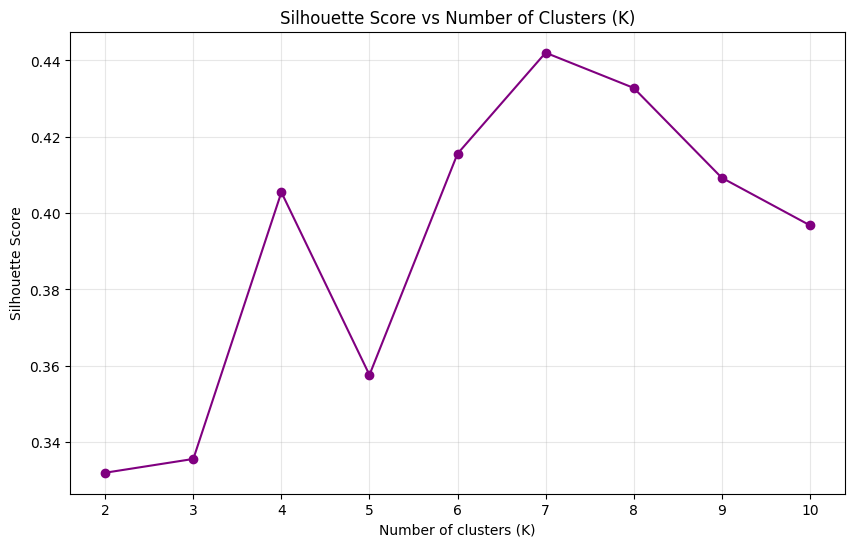

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Plotting the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_scores, marker='o', color='purple', linestyle='-')
plt.title('Silhouette Score vs Number of Clusters (K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.show()

### Observation:
Unlike the Elbow Method (WCSS), where the line always goes down, this graph will show a peak. The value of $K$ at that peak represents the configuration where clusters are most distinct from one another. If the score drops at $K=10$, it proves that more clusters aren't always better!

### Comparison Guide:
1. **Higher Silhouette Score:** Usually indicates more 'distinct' clusters with less noise.
2. **K=4 (Simplicity):** Often captures broad patterns (e.g., Young/Old, High/Low Spend). Easier to manage for marketing.
3. **K=6 (Granularity):** Might uncover smaller niche groups (e.g., specific age groups with unique income levels), but risks 'over-segmenting' the data where clusters overlap too much.